# 🌸 Iris Dataset – Exploratory Data Analysis
> **Tech stack:** Python · Pandas · NumPy · Matplotlib · Seaborn · ydata-profiling  
> **Dataset:** UCI Iris (150 samples, 4 numeric features, 3 species classes)


## 1. Setup & Imports

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from data_profiling import ProfileReport

print('All libraries loaded ✓')

## 2. Load Dataset

In [ ]:
iris_raw = load_iris(as_frame=True)
df = iris_raw.frame.copy()
df.columns = ['sepal_length','sepal_width','petal_length','petal_width','species']
df['species'] = df['species'].map({0:'setosa',1:'versicolor',2:'virginica'})
print(f'Shape: {df.shape}')
df.head()

## 3. Data Quality Check

In [ ]:
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Duplicates:', df.duplicated().sum(), '===')

## 4. Descriptive Statistics

In [ ]:
df.describe().round(3)

In [ ]:
# Per-species statistics
df.groupby('species').agg(['mean','std','min','max']).round(3)

## 5. Automated Profiling Report

In [ ]:
profile = ProfileReport(df, title='Iris Dataset – EDA Report', explorative=True)
profile.to_file('iris_profile_report.html')
print('Report saved to iris_profile_report.html')

## 6. Visualisations

### 6a. Class Distribution

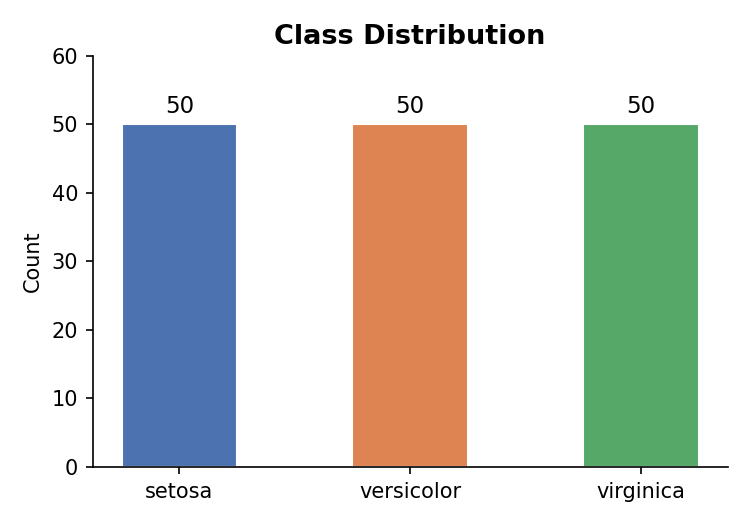

In [ ]:
# Already generated — displayed below
print('Class counts:\n', df.species.value_counts())

### 6b. Box-plots by Species

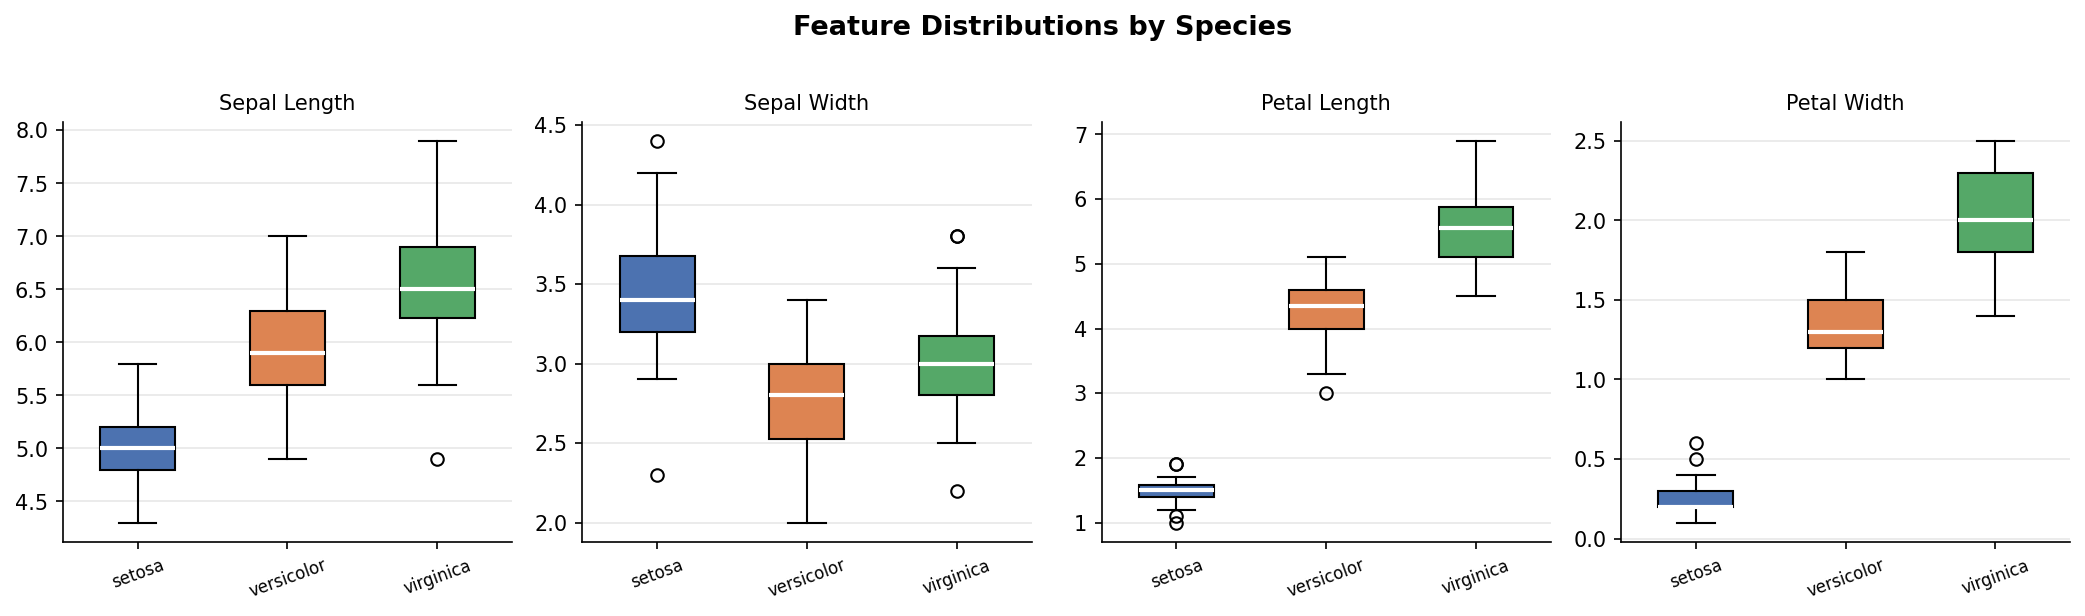

In [ ]:
# Feature spread per class

### 6c. KDE Distributions

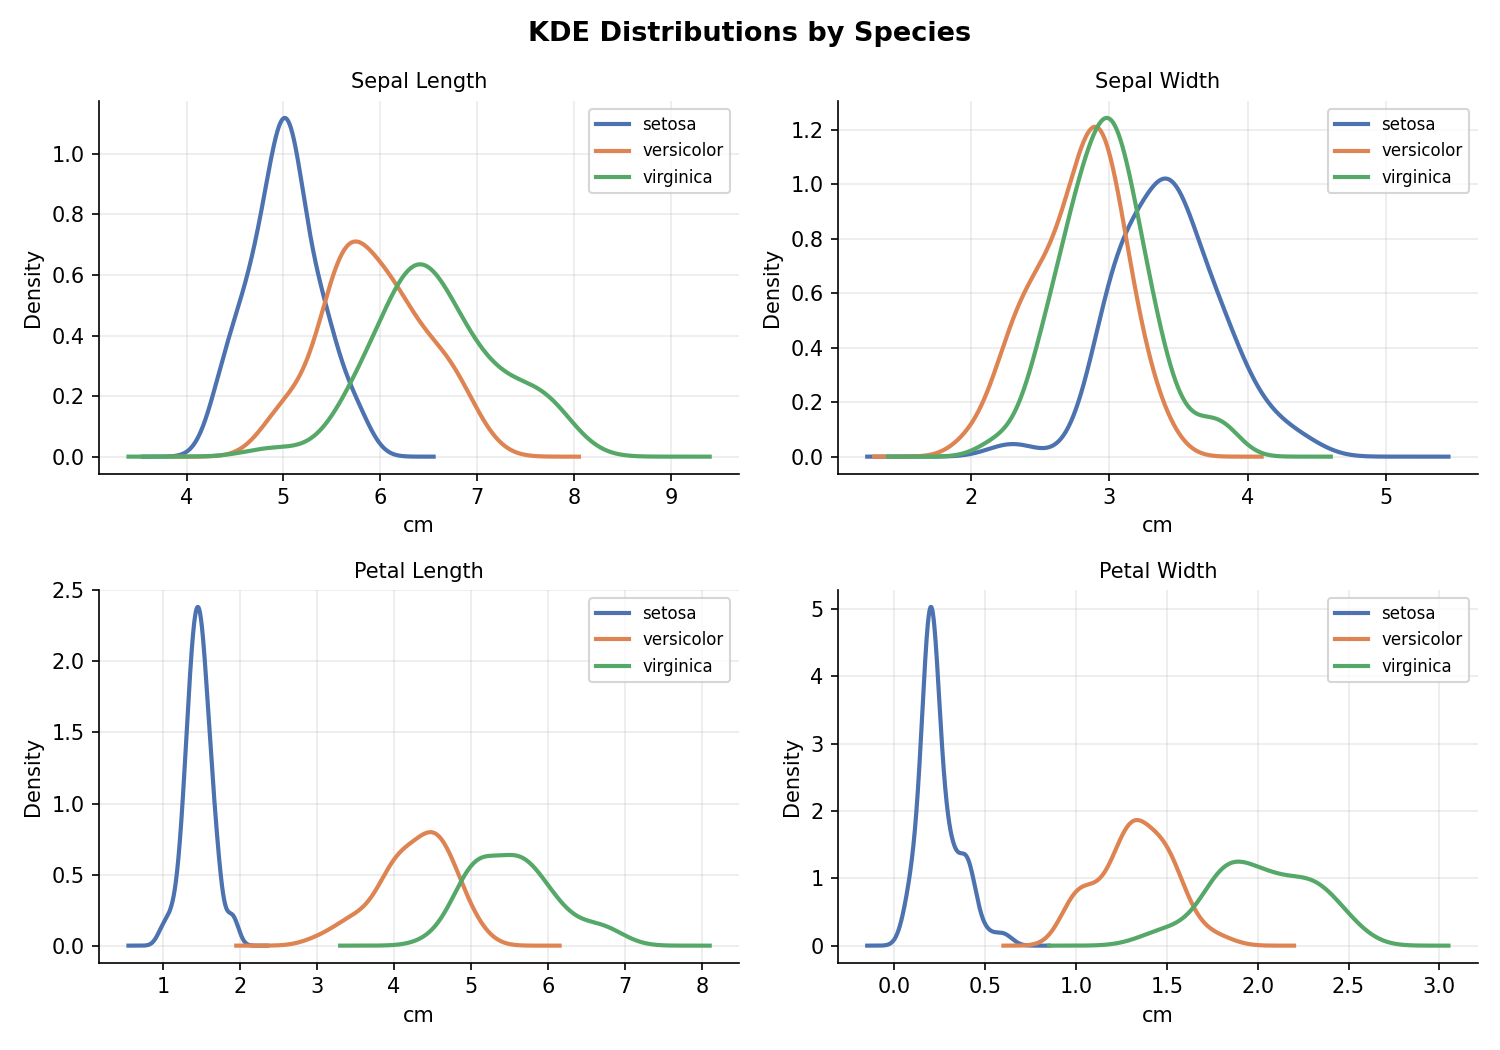

In [ ]:
# Density curves per species

### 6d. Pair-Plot

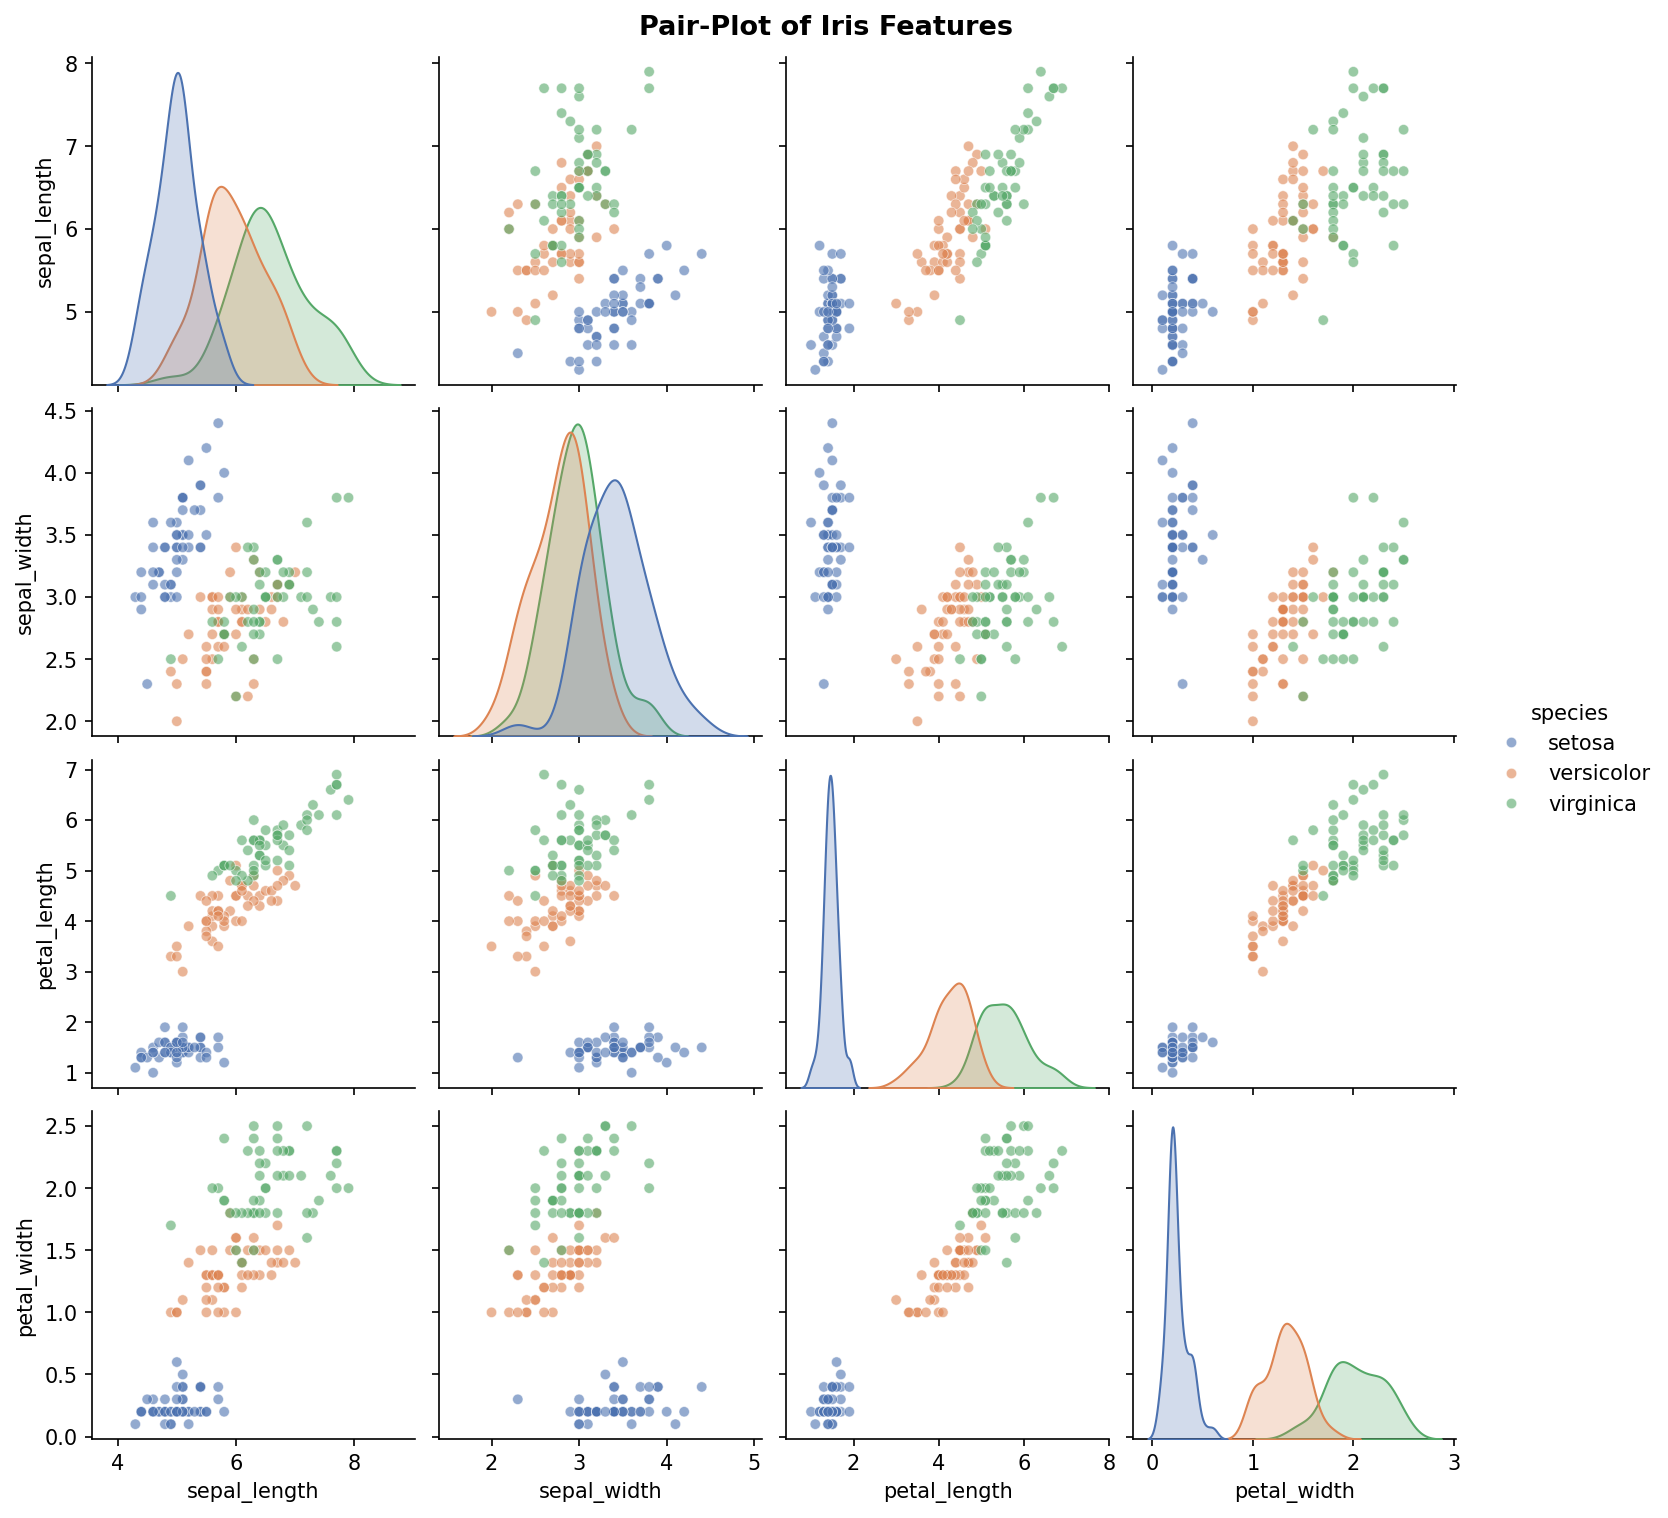

In [ ]:
# Scatter matrix + KDE diagonal

### 6e. Correlation Heatmap

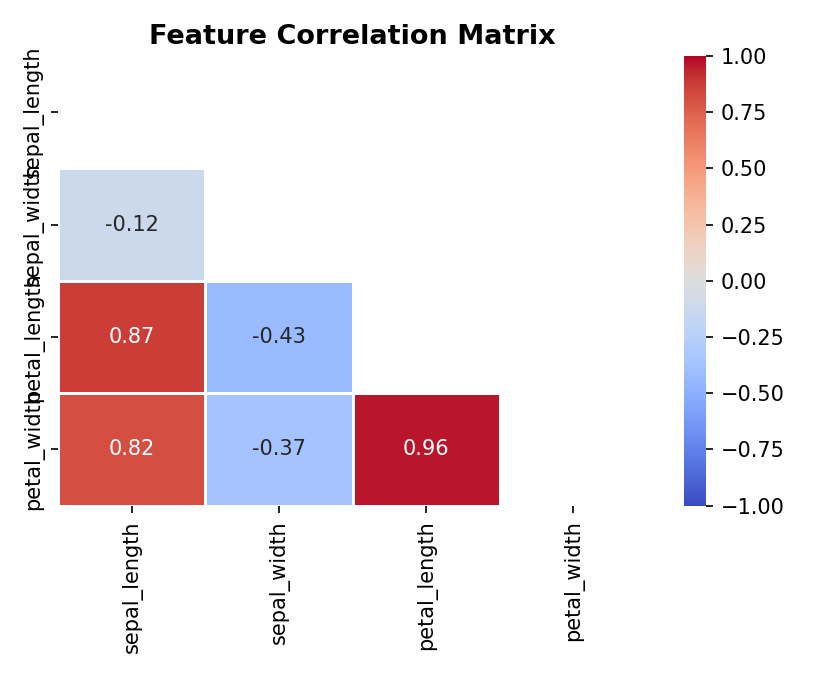

In [ ]:
# Pearson correlations among numeric features

## 7. Key Insights

1. **No missing values or duplicates** – the dataset is perfectly clean and ready for modelling.
2. **Petal features are the strongest discriminators** – petal length and petal width show near-zero overlap between *setosa* and the other two classes.
3. **High petal correlation (r = 0.96)** – petal length and petal width are strongly co-linear, suggesting one could be dropped without much information loss.
4. **Setosa is linearly separable** – all four features clearly isolate setosa from versicolor/virginica; a simple rule like `petal_length < 2.5 cm` achieves 100 % class separation.
5. **Versicolor–Virginica overlap** – these two classes share overlapping sepal distributions, making them harder to separate; petal width is the best single feature to distinguish them.
6. **Balanced dataset** – exactly 50 samples per class eliminates class-imbalance concerns for downstream classification.


## 8. Conclusion

The Iris dataset is clean, balanced, and well-structured. EDA confirms that **petal dimensions drive species classification**, sepal features are noisier, and setosa is trivially separable. The strong petal correlation warrants PCA or feature selection before building high-dimensional models. The automated ydata-profiling report (HTML) provides an interactive deep-dive into distributions, correlations, and alerts.
